# QNP-based SQD implementation for MOF - hardware experiment

This notebook presents a simple Qiskit implementation of the QNP ansatz <br>
https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3/meta <br>
The specific case considered here is the (10,10) active space of the MOF. The simulation involves 20 qubits and 3 layers depth. This is not sufficient to achieve chemical accuracy within the standard VQE approach but, as shown below, noisy sample-based quantum diagonalization (SQD) can overcome these limitations.<br> 
To simplify future simulations on harware, the QNP ansatz uses fixed parameters obtained from Quicksilver (the optimization itself could be challenging in the presence of noise). Additionally, gates that do not or weakly contribute to the final results are removed. In this way the number of gates is decreased to 22 from the 54 of the full 3-layer QNP ansatz. <br>

Set up quantum circuit

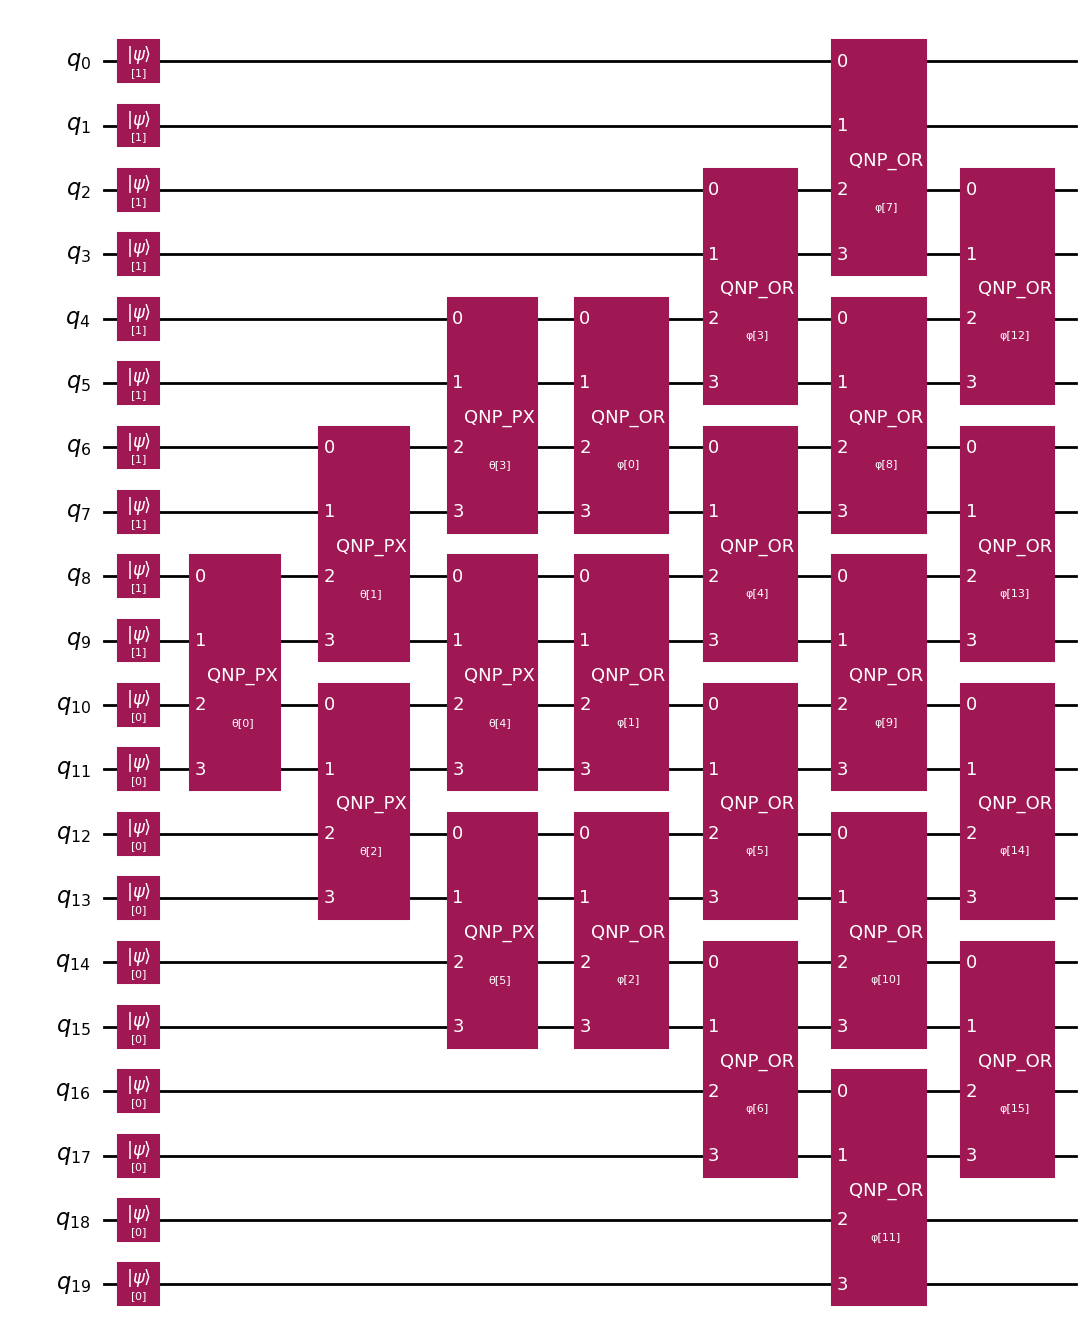

In [1]:
import numpy as np
import sys
sys.path.append('../../../qnp_vqe_qiskit_simulator/qnp_utils')
from qnp_utils import count_QNP_params, initialize_HF
from qnp_utils import QNP_fabric, QNP_PX_GATE, QNP_OR_GATE
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_layers = 3
n_qbits = 20
intfile = '../../../fullci_reference_pyscf/singlet/MOFintegrals.npz'
integrals = np.load(intfile)
nelec = int(integrals['Nelec'])

#n_theta, n_phi = count_QNP_params(n_qbits, n_layers)
#Since we are removing gates that do not contribute + other gates with almost 0 rotation angles
#the number of parameters is set manually
n_theta=6 
n_phi=16

theta = ParameterVector('θ', n_theta)
phi = ParameterVector('φ', n_phi)

qnp_circ = QuantumCircuit(n_qbits)
initialize_HF(qnp_circ,nelec)

#Some gates do not contribute and should be removed from the ansatz for efficiency
#For this reason we build the QNP ansatz explicitly instead of using QNP_fabric 

#First layer
qnp_circ.append(QNP_PX_GATE(theta[0]), [8, 9, 10, 11])
#qnp_circ.barrier()
qnp_circ.append(QNP_PX_GATE(theta[1]), [6, 7, 8, 9])
qnp_circ.append(QNP_PX_GATE(theta[2]), [10, 11, 12, 13])
#qnp_circ.barrier()
iphi = 0 
itheta = 3

#Second layer
for nq in [4,8,12]:
    qnp_circ.append(QNP_PX_GATE(theta[itheta]), [nq, nq+1, nq+2, nq+3])
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
    itheta += 1 
#qnp_circ.barrier()
for nq in [2,6,10,14]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()

#Third layer
for nq in [0,4,8,12,16]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1
#qnp_circ.barrier()
for nq in [2,6,10,14]:
    qnp_circ.append(QNP_OR_GATE(phi[iphi]), [nq, nq+1, nq+2, nq+3])
    iphi += 1

# Draw the main circuit
qnp_circ.draw('mpl')

Set up Hamiltonian 

In [2]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
from qnp_utils import reorder_alphabeta_to_interleaved

#Load the active space integrals defining the Hamiltonian 
H0 = integrals['Ecore']
H1 = integrals['Hact']
H2 = integrals['Iact']

print(f"H0: {H0}")
print(f"H1 type: {type(H1)}, H1 shape {H1.shape}")
print(f"H2 type: {type(H2)}, H2 shape {H2.shape}")

#Setting up the electronic Hamiltonian from H1 and H2 integrals
hamiltonian = ElectronicEnergy.from_raw_integrals(H1, H2)
hamiltonian.nuclear_repulsion_energy = H0 # This is just a constant in the Hamiltonian

#Hamiltonian in second quantization
second_q_H = hamiltonian.second_q_op()

#Fermion to qubit mapping
mapper = JordanWignerMapper()
qubit_jw_H = mapper.map(second_q_H)

#Changing Pauli strings to interleaved order 
pauli_terms = qubit_jw_H.paulis  
coeffs = qubit_jw_H.coeffs
interleaved_pauli = reorder_alphabeta_to_interleaved(pauli_terms)
qubit_jw_H = SparsePauliOp.from_list(list(zip(interleaved_pauli, coeffs)))

H0: 0.0
H1 type: <class 'numpy.ndarray'>, H1 shape (10, 10)
H2 type: <class 'numpy.ndarray'>, H2 shape (10, 10, 10, 10)


Use Qiskit to compute the exact expectation value

Qiskit estimate of ground state energy (exact estimator): -55.008009088056475 Ha
Deviation from reference FCI: 0.2665127738599793 Ha
Deviation of Quicksilver (reduced circuit):  0.26651277340820910 Ha
Deviation of Quicksilver (full circuit):     0.19102860911692687 Ha


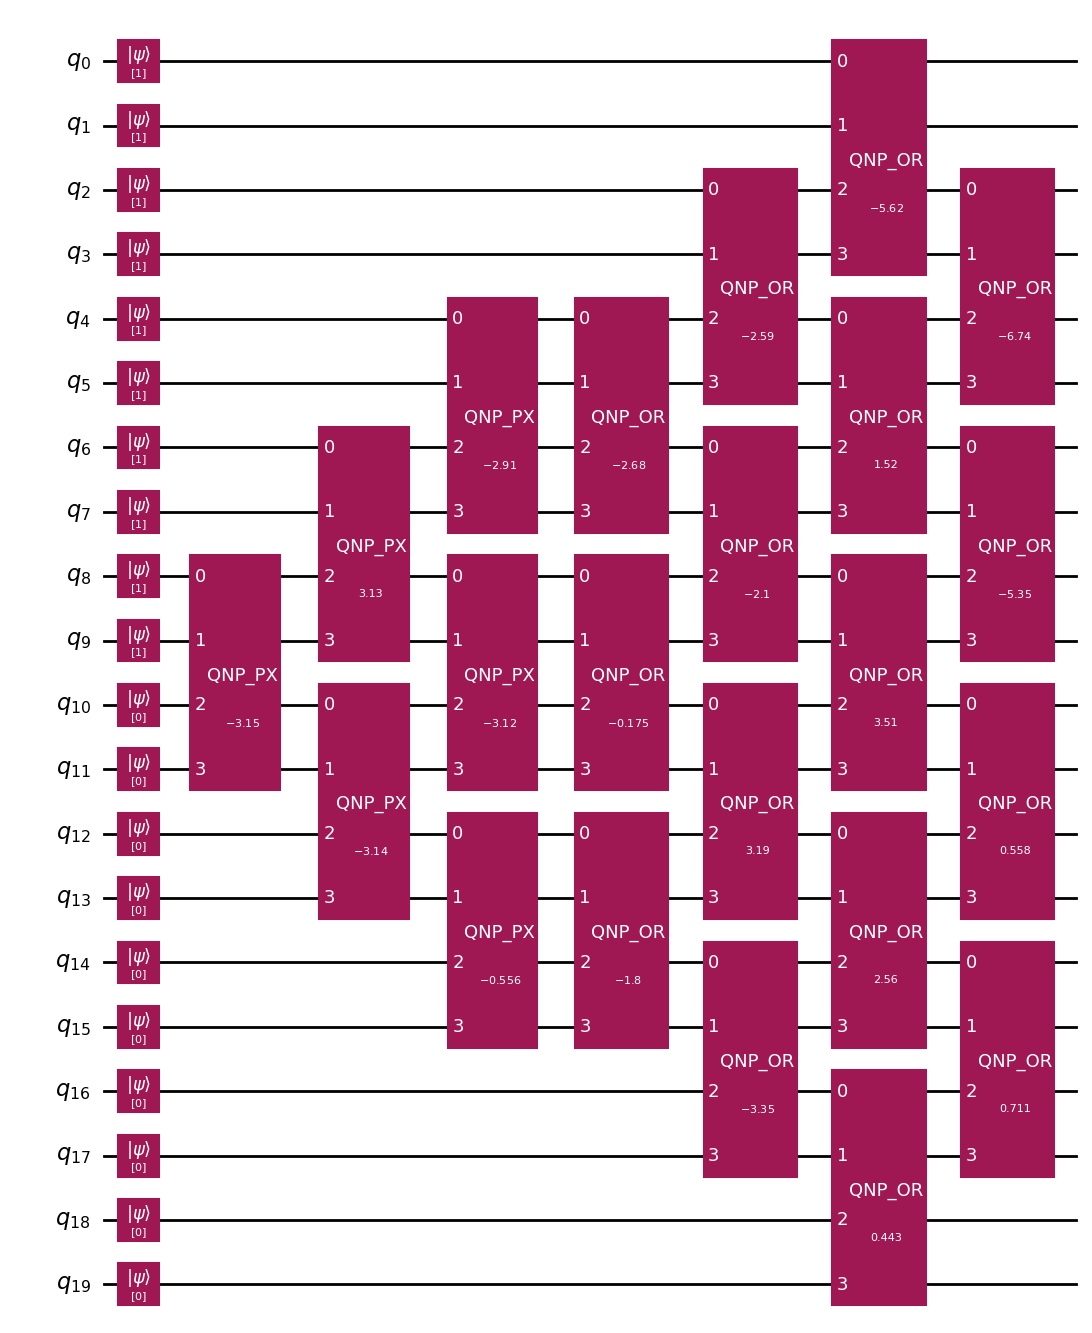

In [3]:
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter, ParameterVector
from qnp_utils import assign_parameters_from_file

#Reference FCI value
E_FCI = integrals['Efci']

exact_estimator = StatevectorEstimator()

parfile='optimized_params.txt'
with open(parfile, 'r') as f:
    opt_params = 2.0*np.array(list(map(float, f.read().strip().split(' '))))

param_values = {}

#First layer
param_values.update({theta[0]: opt_params[2]}) 
param_values.update({theta[1]: opt_params[11]}) 
param_values.update({theta[2]: opt_params[12]}) 

#Second layer
param_values.update({theta[3]: opt_params[19]}) 
param_values.update({theta[4]: opt_params[20]}) 
param_values.update({theta[5]: opt_params[21]})
param_values.update({phi[0]: opt_params[24]}) 
param_values.update({phi[1]: opt_params[25]}) 
param_values.update({phi[2]: opt_params[26]})
 
param_values.update({phi[3]: opt_params[32]}) 
param_values.update({phi[4]: opt_params[33]}) 
param_values.update({phi[5]: opt_params[34]})
param_values.update({phi[6]: opt_params[35]})

#Third layer
param_values.update({phi[7]: opt_params[41]}) 
param_values.update({phi[8]: opt_params[42]})
param_values.update({phi[9]: opt_params[43]}) 
param_values.update({phi[10]: opt_params[44]})
param_values.update({phi[11]: opt_params[45]})

param_values.update({phi[12]: opt_params[50]}) 
param_values.update({phi[13]: opt_params[51]}) 
param_values.update({phi[14]: opt_params[52]})
param_values.update({phi[15]: opt_params[53]})

qnp_fix_param = qnp_circ.assign_parameters(param_values)

results = exact_estimator.run([(qnp_fix_param, qubit_jw_H)]).result()
qiskit_exact_GSenergy=results[0].data.evs+H0

print(f"Qiskit estimate of ground state energy (exact estimator): {qiskit_exact_GSenergy} Ha")
print(f"Deviation from reference FCI: {qiskit_exact_GSenergy-E_FCI} Ha")
print("Deviation of Quicksilver (reduced circuit):  0.26651277340820910 Ha")
print("Deviation of Quicksilver (full circuit):     0.19102860911692687 Ha")
qnp_fix_param.draw('mpl')

### SQD on hardware

The credentials of QC Ware's account have been removed (token="...", instance="...").

In order to obtain an optimally transpiled quantum circuit for the hardware simulation, the transpilation is applied 2000 times and the quantum circuit with the lowest depth is selected. To ensure reproducibility, the transpiled circuit is saved to a file. To perform a new transpilation, uncomment the lines below.

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qpy

#service = QiskitRuntimeService(channel="ibm_cloud", token="...", instance="...")

#All qubits are measured to obtain the bitstrings
qnp_fix_param.measure_all()

#hwbackend = service.backend("ibm_torino")
#pass_manager = generate_preset_pass_manager(optimization_level=3, backend=hwbackend)

#depth = 1e+6
#for i in range(2000):
#    qnp_fix_param_hw_tmp = pass_manager.run(qnp_fix_param)
#    if qnp_fix_param_hw_tmp.depth()<depth:
#        depth = qnp_fix_param_hw_tmp.depth()
#        qnp_fix_param_hw = qnp_fix_param_hw_tmp

#with open('transpiled_torino_QNP_MOF.qpy', 'wb') as fd:
#    qpy.dump(qnp_fix_param_hw, fd)

with open("transpiled_torino_QNP_MOF.qpy", "rb") as fd:
    qnp_fix_param_hw = qpy.load(fd)[0]

print(dict(qnp_fix_param_hw.count_ops()))
print(f"Depth: {qnp_fix_param_hw.depth()}")

{'sx': 639, 'rz': 474, 'cz': 282, 'x': 28, 'reset': 20, 'measure': 20, 'barrier': 1}
Depth: 283




In [5]:
qnp_fix_param_hw.draw('mpl', style="iqp", fold=-1, scale=0.5, idle_wires=False)

Uncomment the cell below to run a new quantum hardware experiment with 100k samples.

In [6]:
#from qiskit_ibm_runtime import SamplerV2 as Sampler

nshots_hw = 100000

#sampler = Sampler(hwbackend)
#job = sampler.run([qnp_fix_param_hw], shots=nshots_hw)

Loading data from a previous experiment; uncomment the lines below to save new results to file.

In [7]:
#result_hw = job.result()[0]
#counts_hw_interleaved = result_hw.data.meas.get_counts()
#np.save("hwbackend_counts_reducedgates.npy", counts_hw_interleaved, allow_pickle=True)

In [8]:
#counts_hw_interleaved = result_hw.data.meas.get_counts()
counts_hw_interleaved = np.load("hwbackend_counts_reducedgates.npy", allow_pickle=True).item()

In [9]:
from qiskit_addon_sqd.counts import counts_to_arrays
# The interleaved bitstrings are converted to the alpha-then-beta convention used by Qiskit
counts_hw={}
for s, val in counts_hw_interleaved.items():
    det_a = ''.join([s[i] for i in range(n_qbits) if i % 2 == 0])
    det_b = ''.join([s[i] for i in range(n_qbits) if i % 2 == 1])
    det_string = det_b+det_a
    counts_hw[det_string] = val

bitstring_matrix_hw, probs_arr_hw = counts_to_arrays(counts_hw)

### Data analysis of the samples obtained from the quantum hardware experiment
In the quantum hardware experiment do we sample the 11 determinants that contribute the most to the exact wavefunction? Missing some of them implies that the simulation is strongly affected by noise.  

In [10]:
pyscf_counts={'00011100001100101111': 0.07660734757443831, '00101100001100011111': 0.07660365812561762, '00101100000110011111': 0.05872813469411152, '00011100001001101111': 0.058721665057563543, '00011100001010011111': 0.028875384152233965, '00101100000101101111': 0.02887044083164174, '00101100001101001111': 0.01992301925435158, '00011100001110001111': 0.019912150034327867, '00011100001011001111': 0.018483618855150756, '00101100000111001111': 0.018483206070267478, '00111100000010011111': 0.014951907144312012}

for bitstring in pyscf_counts.keys():
    if bitstring in counts_hw_interleaved:
        print(f"{bitstring} was sampled {counts_hw_interleaved[bitstring]} in the hardware experiment")
    else:
        print(f"{bitstring} was NOT sampled in the hardware experiment")

00011100001100101111 was sampled 163 in the hardware experiment
00101100001100011111 was sampled 151 in the hardware experiment
00101100000110011111 was sampled 441 in the hardware experiment
00011100001001101111 was sampled 586 in the hardware experiment
00011100001010011111 was sampled 890 in the hardware experiment
00101100000101101111 was sampled 745 in the hardware experiment
00101100001101001111 was sampled 156 in the hardware experiment
00011100001110001111 was sampled 173 in the hardware experiment
00011100001011001111 was sampled 685 in the hardware experiment
00101100000111001111 was sampled 541 in the hardware experiment
00111100000010011111 was sampled 373 in the hardware experiment


Now let's see how many unique bitstrings have the correct number of electrons (10)

Number of elelctrons (hamming weight): 10, Count: 8207
Number of elelctrons (hamming weight): 9, Count: 7865
Number of elelctrons (hamming weight): 11, Count: 6912
Number of elelctrons (hamming weight): 8, Count: 5620
Number of elelctrons (hamming weight): 12, Count: 4401
Number of elelctrons (hamming weight): 7, Count: 3171
Number of elelctrons (hamming weight): 13, Count: 2113
Number of elelctrons (hamming weight): 6, Count: 1425
Number of elelctrons (hamming weight): 14, Count: 845
Number of elelctrons (hamming weight): 5, Count: 511
Number of elelctrons (hamming weight): 15, Count: 254
Number of elelctrons (hamming weight): 4, Count: 131
Number of elelctrons (hamming weight): 16, Count: 69
Number of elelctrons (hamming weight): 3, Count: 30
Number of elelctrons (hamming weight): 17, Count: 17
Number of elelctrons (hamming weight): 2, Count: 4
Number of elelctrons (hamming weight): 18, Count: 3
Number of elelctrons (hamming weight): 1, Count: 1


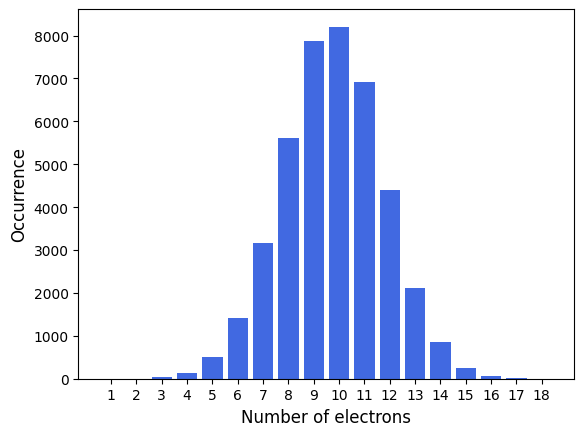

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

# Compute Hamming weights
hamming_weights = [key.count('1') for key in counts_hw.keys()]

# Count occurrences of each Hamming weight
hammingw_counts = Counter(hamming_weights)

# Sort by most to least frequent
sorted_hammingw = dict(sorted(hammingw_counts.items(), key=lambda x: x[1], reverse=True))

# Print results
for weight, count in sorted_hammingw.items():
    print(f"Number of elelctrons (hamming weight): {weight}, Count: {count}")

# Plot results
x_values = sorted(hammingw_counts.keys(), reverse=True)  
y_values = [hammingw_counts[x] for x in x_values]
plt.bar(x_values, y_values, color='royalblue')
plt.xlabel("Number of electrons", fontsize=12)
plt.ylabel("Occurrence", fontsize=12)
x_labels = list(x_values)
plt.xticks(x_labels)
plt.show()

Now let's see how many of the bistrings with the correct number of electrons also have the correct number of electrons for each spin (5 alpha+5 beta since we are considering a spin singlet).

In [12]:
correct_bitstrings = {}

midpoint = n_qbits // 2
num_elec_a = num_elec_b = int(nelec/2)
for bitstring, value in counts_hw.items():
    first_half = bitstring[:midpoint]
    second_half = bitstring[midpoint:]

    if first_half.count("1") == num_elec_b and second_half.count("1") == num_elec_a:
       correct_bitstrings[bitstring] = 1 # Since the number of occurences is not important herem we simply use the value 1

print(f"{len(correct_bitstrings)} out of {sorted_hammingw[nelec]} bitstrings with {nelec} electrons have the correct number of electrons for each spin.")

3958 out of 8207 bitstrings with 10 electrons have the correct number of electrons for each spin.


### Diagonalization in the subspace of the "correct" bitstrings

It is interesting to see the results that can be obtained before configuration recovery. Only the configurations with the correct number of electrons and spin should be included. 

In [13]:
from qiskit_addon_sqd.fermion import solve_fermion

bitstring_matrix_cb, _ = counts_to_arrays(correct_bitstrings)
energy_cb, _, _, spin_sq = solve_fermion(bitstring_matrix_cb, H1, H2)
print(
    "###########################################################################\n"
    f"Ground state energy approximation: {energy_cb}\n"
    "###########################################################################"
)
print(f"Deviation of SQD (hardware experiment before configuration recovery) from reference FCI: {energy_cb-E_FCI} Ha")
print(f"Spin squared {spin_sq}")

###########################################################################
Ground state energy approximation: -55.27152550990504
###########################################################################
Deviation of SQD (hardware experiment before configuration recovery) from reference FCI: 0.0029963520114151265 Ha
Spin squared 0.014548197737805338


### Configuration recovery

In [14]:
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.subsampling import postselect_and_subsample
from qiskit_addon_sqd.fermion import flip_orbital_occupancies
from qiskit_addon_sqd.configuration_recovery import recover_configurations

# SQD options
iterations = 5
rand_seed = 42

# Eigenstate solver options
n_batches = 1
samples_per_batch = nshots_hw
max_davidson_cycles = 200

num_elec_a = num_elec_b = int(nelec/2)
num_orbitals = int(n_qbits/2)

energy_hist = np.zeros((iterations, n_batches))  # energy history
occupancy_hist = np.zeros((iterations, 2 * num_orbitals))
occupancies_bitwise = None  # orbital i corresponds to column i in bitstring matrix

for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we just post-select from the full bitstring set based on hamming weight.
    if occupancies_bitwise is None:
        bs_mat_tmp = bitstring_matrix_hw
        probs_arr_tmp = probs_arr_hw

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_hw,
            probs_arr_hw,
            occupancies_bitwise,
            num_elec_a,
            num_elec_b,
            rand_seed=rand_seed,
        )

    # Throw out configurations with incorrect particle number in either the spin-up or spin-down systems
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rand_seed,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    energy_tmp = np.zeros(n_batches)
    occs_tmp = np.zeros((n_batches, 2 * num_orbitals))
    for j in range(n_batches):
        energy_sci, _, avg_occs, spin_sq = solve_fermion(
            batches[j],
            H1,
            H2,
        )
        print(f"Spin squared {spin_sq}")
        energy_sci += H0
        energy_tmp[j] = energy_sci
        occs_tmp[j, :num_orbitals] = avg_occs[0]
        occs_tmp[j, num_orbitals:] = avg_occs[1]

    # Combine batch results
    avg_occupancies = np.mean(occs_tmp, axis=0)
    # The occupancies from the solver should be flipped to match the bits in the bitstring matrix.
    occupancies_bitwise = flip_orbital_occupancies(avg_occupancies)

    # Track optimization history
    energy_hist[i, :] = energy_tmp
    occupancy_hist[i, :] = avg_occupancies

min_e = np.min(energy_hist) # Submit this value
print(
    "###########################################################################\n"
    f"Ground state energy approximation: {min_e}\n"
    "###########################################################################"
)

#plot_histogram(counts)

Starting configuration recovery iteration 0
Spin squared 0.014548197737805338
Starting configuration recovery iteration 1
Spin squared 0.0005017806165635215
Starting configuration recovery iteration 2
Spin squared 0.0003382394271102843
Starting configuration recovery iteration 3
Spin squared 0.0003382394271102843
Starting configuration recovery iteration 4
Spin squared 0.0003382394271102843
###########################################################################
Ground state energy approximation: -55.274360602275586
###########################################################################


In [15]:
print(f"Deviation of SQD (hardware experiment) from reference FCI: {min_e-E_FCI} Ha")

Deviation of SQD (hardware experiment) from reference FCI: 0.00016125964086910471 Ha
